# LCIA of European hydrogen distribution markets

This is the master notebook for selecting prospective Brightway databases, running the complete LCIA workflow, reviewing quality-control tables, and creating plots. Calculation and classification logic lives in `run_analysis.py` and `mapping.py`; this notebook contains no LCIA algorithms. The functional unit is **1 kg of hydrogen, gaseous, low pressure**.

## 1. Imports and display settings

In [1]:
from pathlib import Path
import math
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import bw2data as bd

candidate_dirs = [Path.cwd(), Path.cwd() / 'examples' / 'h2-distribution_LCIA']
ANALYSIS_DIR = next((path.resolve() for path in candidate_dirs if (path / 'config.py').exists()), None)
if ANALYSIS_DIR is None:
    raise FileNotFoundError('Run this notebook from its own folder or from the repository root.')
if str(ANALYSIS_DIR) not in sys.path:
    sys.path.insert(0, str(ANALYSIS_DIR))

import config as cfg
from run_analysis import run_analysis, safe_path_component

pd.set_option('display.max_colwidth', 140)
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'font.size': 12, 'axes.titlesize': 15, 'axes.labelsize': 13,
    'xtick.labelsize': 11, 'ytick.labelsize': 11, 'legend.fontsize': 10,
    'legend.title_fontsize': 11, 'figure.titlesize': 18,
})

16:07:22+0200 [warning  ] Can't import `SimaProBlockCSVImporter` - please install `bw2io` with `pip install bw2io[multifunctional]` or install `multifunctional` and `bw_simapro_csv` manually.


## 2. Choose project and databases

This is the only cell that normally needs editing. Run the notebook with the repository's `brightway25` conda environment. Multiple databases are supported; each receives its own results subfolder. The regional steel comparison is optional because it adds a separate analysis scope and substantial runtime.

In [2]:
PROJECT = 'ecoinvent-3.12-cutoff'
DATABASES = [
    "ecoinvent-3.12-cutoff_remind-SSP1-PkBudg650_2050_04_full",
    "ecoinvent-3.12-cutoff_message-SSP1-VL_2050_04_full",
]
RUN_REGIONAL_STEEL = False
EXPORT_RESULTS = True
SAVE_PLOTS = True

In [1]:
bd.projects.set_current('ecoinvent-3.12-cutoff')
list(bd.databases)

NameError: name 'bd' is not defined

## 3. Run all calculations

The runner selects exact market datasets, calculates EF 3.1, hydrogen-inclusive premise GWP, and aggregate CED scores, performs process and life-cycle-stage contribution analyses, and enforces all reconciliation checks before returning.

In [4]:
if not DATABASES:
    raise ValueError('Select at least one database.')
if len(DATABASES) != len(set(DATABASES)):
    raise ValueError('DATABASES contains duplicate names.')

results_by_database = {}
for database_name in DATABASES:
    output_dir = (
        cfg.RESULTS_DIR
        if len(DATABASES) == 1
        else cfg.RESULTS_DIR / safe_path_component(database_name)
    )
    print(f'Running {database_name} ...')
    results_by_database[database_name] = run_analysis(
        project=PROJECT,
        database_name=database_name,
        output_dir=output_dir,
        export=EXPORT_RESULTS,
        run_regional_steel=RUN_REGIONAL_STEEL,
    )
    print(f'Finished {database_name}')

Running ecoinvent-3.12-cutoff_remind-SSP1-PkBudg650_2050_04_full ...
Using biosphere database: biosphere-3.12 (version (3, 12))
Adding ('IPCC 2021', 'climate change', 'GWP 20a, incl. H')
Converting to ecoinvent 3.10+ biosphere names
Applying strategy: csv_restore_tuples
Applying strategy: csv_numerize
Applying strategy: csv_drop_unknown
Applying strategy: set_biosphere_type
Applying strategy: drop_unspecified_subcategories
Applying strategy: link_iterable_by_fields
Applying strategy: drop_falsey_uncertainty_fields_but_keep_zeros
Applying strategy: convert_uncertainty_types_to_integers
Applied 8 strategies in 0.81 seconds
Dropped 46 unlinked lower stratosphere + upper troposphere flows
Wrote 1 LCIA methods with 202 characterization factors
Adding ('IPCC 2021', 'climate change', 'GWP 100a, incl. H')
Converting to ecoinvent 3.10+ biosphere names
Applying strategy: csv_restore_tuples
Applying strategy: csv_numerize
Applying strategy: csv_drop_unknown
Applying strategy: set_biosphere_type
A

C:\Users\ac145674\coding_projects\premise_h2-distribution\examples\h2-distribution_LCIA\run_analysis.py:1071: UserWarning: No market was generated for these European sectors in this scenario: Heating
  selected, market_order, sector_order, selection_df = select_markets(
C:\Users\ac145674\coding_projects\premise_h2-distribution\examples\h2-distribution_LCIA\run_analysis.py:1071: UserWarning: Sector markets are unavailable at RER; using mapped IAM location(s) ['EUR'].
  selected, market_order, sector_order, selection_df = select_markets(


Finished ecoinvent-3.12-cutoff_remind-SSP1-PkBudg650_2050_04_full
Running ecoinvent-3.12-cutoff_message-SSP1-VL_2050_04_full ...
Using biosphere database: biosphere-3.12 (version (3, 12))
Adding ('IPCC 2021', 'climate change', 'GWP 20a, incl. H')
Converting to ecoinvent 3.10+ biosphere names
Applying strategy: csv_restore_tuples
Applying strategy: csv_numerize
Applying strategy: csv_drop_unknown
Applying strategy: set_biosphere_type
Applying strategy: drop_unspecified_subcategories
Applying strategy: link_iterable_by_fields
Applying strategy: drop_falsey_uncertainty_fields_but_keep_zeros
Applying strategy: convert_uncertainty_types_to_integers
Applied 8 strategies in 0.62 seconds
Dropped 46 unlinked lower stratosphere + upper troposphere flows
Wrote 1 LCIA methods with 202 characterization factors
Adding ('IPCC 2021', 'climate change', 'GWP 100a, incl. H')
Converting to ecoinvent 3.10+ biosphere names
Applying strategy: csv_restore_tuples
Applying strategy: csv_numerize
Applying strate

LookupError: No European sector-specific hydrogen markets were found.

## 4. Selection and quality-control review

Review the exact datasets and both reconciliation layers before interpreting plots. Missing sector markets are scenario results: premise creates them only where modeled sector demand is positive.

In [ ]:
for database_name, result in results_by_database.items():
    print(f'\n{database_name}')
    display(result.table('selection'))
    display(result.table('methods'))
    display(result.table('Stage classification audit'))
    display(result.table('Stage reconciliation'))
    display(result.table('Hotspot reconciliation'))
    if RUN_REGIONAL_STEEL:
        display(result.table('Steel-region reconciliation'))


ecoinvent-3.12-cutoff_remind-SSP1-PkBudg650_2050_04_full


,comparison label,name,reference product,location,unit,database key
0,Generic,"market for hydrogen, gaseous, low pressure","hydrogen, gaseous, low pressure",RER,kilogram,"(ecoinvent-3.12-cutoff_remind-SSP1-PkBudg650_2050_04_full, cfb1e2f766b7439583b88158234cc559)"
1,Transport,"market for hydrogen, gaseous, low pressure, for transport","hydrogen, gaseous, low pressure",EUR,kilogram,"(ecoinvent-3.12-cutoff_remind-SSP1-PkBudg650_2050_04_full, 701afb5021dd4e04ab623bd1676e7cec)"
2,Chemicals,"market for hydrogen, gaseous, low pressure, for chemicals","hydrogen, gaseous, low pressure",EUR,kilogram,"(ecoinvent-3.12-cutoff_remind-SSP1-PkBudg650_2050_04_full, 861ff0cc677442ed8f2a15dc177116aa)"
3,Steel,"market for hydrogen, gaseous, low pressure, for steel","hydrogen, gaseous, low pressure",EUR,kilogram,"(ecoinvent-3.12-cutoff_remind-SSP1-PkBudg650_2050_04_full, c1d6e983bcbe42d8a57bec69b85ebfb9)"
4,Cement,"market for hydrogen, gaseous, low pressure, for cement","hydrogen, gaseous, low pressure",EUR,kilogram,"(ecoinvent-3.12-cutoff_remind-SSP1-PkBudg650_2050_04_full, d4276388184540c2adc386d92e02657f)"
5,Other end uses,"market for hydrogen, gaseous, low pressure, for other end uses","hydrogen, gaseous, low pressure",EUR,kilogram,"(ecoinvent-3.12-cutoff_remind-SSP1-PkBudg650_2050_04_full, 369bb524c9f848c28bec2bb0cf6e6326)"


,method,impact category,indicator,unit
0,"(EF v3.1, acidification, accumulated exceedance (AE))",acidification,accumulated exceedance (AE),mol H+-Eq
1,"(EF v3.1, climate change, global warming potential (GWP100))",climate change,global warming potential (GWP100),kg CO2-Eq
2,"(EF v3.1, climate change: biogenic, global warming potential (GWP100))",climate change: biogenic,global warming potential (GWP100),kg CO2-Eq
3,"(EF v3.1, climate change: fossil, global warming potential (GWP100))",climate change: fossil,global warming potential (GWP100),kg CO2-Eq
4,"(EF v3.1, climate change: land use and land use change, global warming potential (GWP100))",climate change: land use and land use change,global warming potential (GWP100),kg CO2-Eq
5,"(EF v3.1, ecotoxicity: freshwater, comparative toxic unit for ecosystems (CTUe))",ecotoxicity: freshwater,comparative toxic unit for ecosystems (CTUe),CTUe
6,"(EF v3.1, ecotoxicity: freshwater, inorganics, comparative toxic unit for ecosystems (CTUe))","ecotoxicity: freshwater, inorganics",comparative toxic unit for ecosystems (CTUe),CTUe
7,"(EF v3.1, ecotoxicity: freshwater, organics, comparative toxic unit for ecosystems (CTUe))","ecotoxicity: freshwater, organics",comparative toxic unit for ecosystems (CTUe),CTUe
8,"(EF v3.1, energy resources: non-renewable, abiotic depletion potential (ADP): fossil fuels)",energy resources: non-renewable,abiotic depletion potential (ADP): fossil fuels,"MJ, net calorific value"
9,"(EF v3.1, eutrophication: freshwater, fraction of nutrients reaching freshwater end compartment (P))",eutrophication: freshwater,fraction of nutrients reaching freshwater end compartment (P),kg P-Eq


,market,market location,provider,provider product,provider unit,provider location,provider key,demand amount,stage,substage,component,classification rule
0,Generic,RER,"hydrogen production, gaseous, 30 bar, from PEM electrolysis, from grid electricity","hydrogen, gaseous, 30 bar",kilogram,EUR,"(ecoinvent-3.12-cutoff_remind-SSP1-PkBudg650_2050_04_full, 37b1d07e81ff4ef19e28d81f237f7f87)",6.621985e-01,Production,Production technology,PEM electrolysis,hydrogen production activity
1,Generic,RER,"hydrogen production, gaseous, 25 bar, from gasification of woody biomass in entrained flow gasifier, at gasification plant","hydrogen, gaseous, 25 bar",kilogram,EUR,"(ecoinvent-3.12-cutoff_remind-SSP1-PkBudg650_2050_04_full, efaf3da7aa5f44ecb0af34ffafd2d7c4)",3.633740e-06,Production,Production technology,Biomass gasification,hydrogen production activity
2,Generic,RER,"hydrogen production, gaseous, 25 bar, from gasification of woody biomass in entrained flow gasifier, with CCS, at gasification plant","hydrogen, gaseous, 25 bar",kilogram,EUR,"(ecoinvent-3.12-cutoff_remind-SSP1-PkBudg650_2050_04_full, b8d42f7c276b40d0bedc718c17ebcd48)",3.331903e-01,Production,Production technology,Biomass gasification with CCS,hydrogen production activity
3,Generic,RER,"hydrogen production, coal gasification, with CCS","hydrogen, gaseous, low pressure",kilogram,EUR,"(ecoinvent-3.12-cutoff_remind-SSP1-PkBudg650_2050_04_full, 6b97ee1475fc4763b6623664477886be)",1.094500e-06,Production,Production technology,Coal gasification with CCS,hydrogen production activity
4,Generic,RER,"hydrogen production, steam methane reforming, with CCS","hydrogen, gaseous, low pressure",kilogram,EUR,"(ecoinvent-3.12-cutoff_remind-SSP1-PkBudg650_2050_04_full, 45811ec5a21e4cc98066ee5a481ca94e)",4.606488e-03,Production,Production technology,Steam methane reforming with CCS,hydrogen production activity
5,Generic,RER,"hydrogen supply, distributed by pipeline","hydrogen, gaseous, from pipeline",kilogram,EUR,"(ecoinvent-3.12-cutoff_remind-SSP1-PkBudg650_2050_04_full, 1ca5494e631d4f32b2e60db1f4bf79b9)",1.000000e+00,Distribution,Transport,Pipeline distribution,exact transport activity
6,Generic,RER,compressor assembly for transmission hydrogen pipeline,"compressor, for hydrogen transmission",unit,RER,"(ecoinvent-3.12-cutoff_remind-SSP1-PkBudg650_2050_04_full, 26b9a7ca463c4f8b96495542403b5cc8)",3.227031e-11,Distribution,Conversion,Compression (pipeline),pipeline compression input
7,Generic,RER,"market group for electricity, low voltage","electricity, low voltage",kilowatt hour,EUR,"(ecoinvent-3.12-cutoff_remind-SSP1-PkBudg650_2050_04_full, 13f887da454449da9d91f12bd7f18f05)",1.816554e+00,Distribution,Conversion,Compression (pipeline),pipeline compression input
8,Transport,EUR,"hydrogen production, gaseous, 30 bar, from PEM electrolysis, from grid electricity","hydrogen, gaseous, 30 bar",kilogram,EUR,"(ecoinvent-3.12-cutoff_remind-SSP1-PkBudg650_2050_04_full, 37b1d07e81ff4ef19e28d81f237f7f87)",6.621985e-01,Production,Production technology,PEM electrolysis,hydrogen production activity
9,Transport,EUR,"hydrogen production, gaseous, 25 bar, from gasification of woody biomass in entrained flow gasifier, at gasification plant","hydrogen, gaseous, 25 bar",kilogram,EUR,"(ecoinvent-3.12-cutoff_remind-SSP1-PkBudg650_2050_04_full, efaf3da7aa5f44ecb0af34ffafd2d7c4)",3.633740e-06,Production,Production technology,Biomass gasification,hydrogen production activity


,market,method,impact category,unit,total score,Layer 1 reconstructed score,Layer 1 difference,Layer 2 reconstructed score,Layer 2 difference
0,Generic,"(IPCC 2021, climate change, GWP 100a, incl. H)","climate change — GWP 100a, incl. H (premise_gwp)",kg CO2-Eq,0.589634,0.589634,2.329026e-12,0.589634,4.054260e-09
1,Transport,"(IPCC 2021, climate change, GWP 100a, incl. H)","climate change — GWP 100a, incl. H (premise_gwp)",kg CO2-Eq,0.617911,0.617911,-9.857085e-10,0.617911,3.066223e-09
2,Chemicals,"(IPCC 2021, climate change, GWP 100a, incl. H)","climate change — GWP 100a, incl. H (premise_gwp)",kg CO2-Eq,0.567427,0.567427,-1.321247e-09,0.567427,2.730684e-09
3,Steel,"(IPCC 2021, climate change, GWP 100a, incl. H)","climate change — GWP 100a, incl. H (premise_gwp)",kg CO2-Eq,0.647782,0.647782,-2.090425e-09,0.647782,1.961506e-09
4,Cement,"(IPCC 2021, climate change, GWP 100a, incl. H)","climate change — GWP 100a, incl. H (premise_gwp)",kg CO2-Eq,0.647782,0.647782,-2.090425e-09,0.647782,1.961506e-09
5,Other end uses,"(IPCC 2021, climate change, GWP 100a, incl. H)","climate change — GWP 100a, incl. H (premise_gwp)",kg CO2-Eq,0.652984,0.652984,-2.941859e-10,0.652984,3.757745e-09


,market,method,impact category,unit,total score,Layer 1 reconstructed score,Layer 1 difference,Layer 2 reconstructed score,Layer 2 difference
0,Generic,"(EF v3.1, acidification, accumulated exceedance (AE))",acidification,mol H+-Eq,1.824544e-02,1.824544e-02,-4.750107e-11,1.824544e-02,8.678175e-11
1,Transport,"(EF v3.1, acidification, accumulated exceedance (AE))",acidification,mol H+-Eq,1.908585e-02,1.908585e-02,-6.275067e-11,1.908585e-02,7.153215e-11
2,Chemicals,"(EF v3.1, acidification, accumulated exceedance (AE))",acidification,mol H+-Eq,1.804448e-02,1.804448e-02,-5.947945e-11,1.804448e-02,7.480336e-11
3,Steel,"(EF v3.1, acidification, accumulated exceedance (AE))",acidification,mol H+-Eq,1.919670e-02,1.919670e-02,-7.246321e-11,1.919670e-02,6.181961e-11
4,Cement,"(EF v3.1, acidification, accumulated exceedance (AE))",acidification,mol H+-Eq,1.919670e-02,1.919670e-02,-7.246321e-11,1.919670e-02,6.181961e-11
5,Other end uses,"(EF v3.1, acidification, accumulated exceedance (AE))",acidification,mol H+-Eq,1.939987e-02,1.939987e-02,-5.060142e-11,1.939987e-02,8.368139e-11
6,Generic,"(IPCC 2021, climate change, GWP 100a, incl. H)","climate change — GWP 100a, incl. H (premise_gwp)",kg CO2-Eq,5.896335e-01,5.896335e-01,2.329026e-12,5.896335e-01,4.054260e-09
7,Transport,"(IPCC 2021, climate change, GWP 100a, incl. H)","climate change — GWP 100a, incl. H (premise_gwp)",kg CO2-Eq,6.179114e-01,6.179114e-01,-9.857085e-10,6.179114e-01,3.066223e-09
8,Chemicals,"(IPCC 2021, climate change, GWP 100a, incl. H)","climate change — GWP 100a, incl. H (premise_gwp)",kg CO2-Eq,5.674273e-01,5.674273e-01,-1.321247e-09,5.674273e-01,2.730684e-09
9,Steel,"(IPCC 2021, climate change, GWP 100a, incl. H)","climate change — GWP 100a, incl. H (premise_gwp)",kg CO2-Eq,6.477819e-01,6.477819e-01,-2.090425e-09,6.477819e-01,1.961506e-09


## 5. Accessible, non-repeating visual encoding

A single registry assigns every categorical label one stable color across every database and figure. Different labels never share a color; the code raises instead of recycling the palette. Hatches, markers, and line styles provide redundant encodings for color-vision deficiencies. Heatmaps use a diverging brown–blue-green scale with a neutral midpoint and printed values.

In [ ]:
def categorical_labels(results):
    labels = set(results.market_order)
    labels.update(results.table('Hotspot process groups')['component'].dropna().astype(str))
    labels.update(results.table('Stage Layer 1')['component'].dropna().astype(str))
    labels.update(results.table('Distribution processes')['process'].dropna().astype(str))
    if 'Steel-region order' in results.tables:
        labels.update(results.table('Steel-region order')['region'].dropna().astype(str))
        labels.update(results.table('Steel-region Layer 1')['component'].dropna().astype(str))
        labels.update(results.table('Steel-region distribution')['process'].dropna().astype(str))
    return labels

all_labels = sorted(set().union(*(categorical_labels(result) for result in results_by_database.values())))
if len(all_labels) > len(cfg.ACCESSIBLE_CATEGORICAL_COLORS):
    raise RuntimeError(
        f'{len(all_labels)} categorical labels require unique colors, but the configured accessible palette '
        f'contains {len(cfg.ACCESSIBLE_CATEGORICAL_COLORS)}. Extend the palette; colors will not be recycled.'
    )
COLOR = dict(zip(all_labels, cfg.ACCESSIBLE_CATEGORICAL_COLORS))
HATCH = {label: cfg.HATCHES[i % len(cfg.HATCHES)] for i, label in enumerate(all_labels)}
MARKER = {label: cfg.MARKERS[i % len(cfg.MARKERS)] for i, label in enumerate(all_labels)}
LINESTYLE = {label: cfg.LINESTYLES[i % len(cfg.LINESTYLES)] for i, label in enumerate(all_labels)}
assert len(set(COLOR.values())) == len(COLOR)
print(f'Assigned {len(COLOR)} unique categorical colors without reuse.')

Assigned 25 unique categorical colors without reuse.


In [ ]:
def finish_figure(fig, result, plot_name, *, rect=None):
    if rect is None:
        fig.tight_layout()
    else:
        fig.tight_layout(rect=rect)
    if SAVE_PLOTS:
        result.output_dir.mkdir(parents=True, exist_ok=True)
        path = result.output_dir / cfg.PLOT_FILENAMES[plot_name]
        fig.savefig(path, dpi=180, bbox_inches='tight', facecolor='white')
        print(f'Saved {path}')
    plt.show()

def plot_absolute_impacts(result):
    scores = result.table('scores')
    categories = scores['impact category'].drop_duplicates().tolist()
    ncols, nrows = 3, math.ceil(len(categories) / 3)
    fig, axes = plt.subplots(nrows, ncols, figsize=(22, 5.2 * nrows), squeeze=False)
    for ax, category in zip(axes.ravel(), categories):
        subset = scores[scores['impact category'] == category].set_index('market').reindex(result.market_order)
        values = subset['score per kg H2'].to_numpy(dtype=float)
        bars = ax.bar(np.arange(len(result.market_order)), values, color=[COLOR[x] for x in result.market_order])
        for bar, label in zip(bars, result.market_order):
            bar.set_hatch(HATCH[label])
        ax.axhline(0, color='black', linewidth=0.8)
        ax.set_title(category, pad=12)
        ax.set_ylabel(f"{subset['unit'].iloc[0]} / kg H2")
        ax.set_xticks(np.arange(len(result.market_order)), result.market_order, rotation=38, ha='right')
        for bar, value in zip(bars, values):
            ax.annotate(f'{value:.2e}', (bar.get_x() + bar.get_width()/2, value),
                        xytext=(4, 10 if value >= 0 else -12), textcoords='offset points',
                        ha='center', fontsize=9, rotation=90)
        nonzero = np.abs(values[np.isfinite(values) & (values != 0)])
        if len(nonzero) and nonzero.max() / nonzero.min() > 1000:
            ax.set_yscale('symlog', linthresh=max(nonzero.min(), 1e-30))
    for ax in axes.ravel()[len(categories):]:
        ax.set_visible(False)
    fig.suptitle(f'Absolute LCIA impacts — {result.database_name}', y=1.002)
    finish_figure(fig, result, 'absolute impacts')

def plot_baseline_heatmap(result):
    comparison = result.table('RER comparison')
    categories = result.table('scores')['impact category'].drop_duplicates().tolist()
    matrix = comparison.pivot(index='impact category', columns='market', values='difference (%)').reindex(
        index=categories, columns=result.sector_order)
    finite = matrix.to_numpy(dtype=float)
    finite = finite[np.isfinite(finite)]
    limit = max(10.0, np.percentile(np.abs(finite), 95)) if len(finite) else 100.0
    fig, ax = plt.subplots(figsize=(max(11, 2 * len(result.sector_order)), max(9, .58 * len(categories))))
    image = ax.imshow(matrix, cmap='BrBG', vmin=-limit, vmax=limit, aspect='auto')
    ax.set_xticks(np.arange(len(result.sector_order)), result.sector_order, rotation=35, ha='right')
    ax.set_yticks(np.arange(len(categories)), categories)
    for i in range(matrix.shape[0]):
        for j in range(matrix.shape[1]):
            value = matrix.iat[i, j]
            if np.isfinite(value):
                ax.text(j, i, f'{value:+.0f}%', ha='center', va='center', fontsize=9,
                        color='white' if abs(value) > .55 * limit else 'black')
    fig.colorbar(image, ax=ax, label='Difference from generic market, %')
    ax.set_title(f'Sector markets relative to Generic (RER) — {result.database_name}')
    finish_figure(fig, result, 'baseline heatmap')

def plot_ef_spider(result):
    ratios = result.table('EF 3.1 spider ratios').set_index('impact category')
    categories = ratios.index.tolist()
    angles = np.linspace(0, 2*np.pi, len(categories), endpoint=False)
    xdir, ydir = np.sin(angles), np.cos(angles)
    radial_max = max(1.1, float(ratios[result.sector_order].max().max()) * 1.08)
    fig, ax = plt.subplots(figsize=(16, 16))
    circle_angles = np.linspace(0, 2*np.pi, 361)
    for level in sorted(set(np.linspace(0, radial_max, 5).tolist() + [1.0])):
        if level == 0: continue
        ax.plot(level*np.sin(circle_angles), level*np.cos(circle_angles),
                color='black' if np.isclose(level, 1) else '#bdbdbd',
                linewidth=2.0 if np.isclose(level, 1) else .7,
                linestyle='--' if np.isclose(level, 1) else ':')
        ax.text(0, level, f'{level:.2g}', fontsize=10, color='#555555')
    for xd, yd, label in zip(xdir, ydir, categories):
        ax.plot([0, radial_max*xd], [0, radial_max*yd], color='#d0d0d0', linewidth=.6)
        ha = 'center' if abs(xd) < .15 else ('left' if xd > 0 else 'right')
        va = 'center' if abs(yd) < .15 else ('bottom' if yd > 0 else 'top')
        ax.text(radial_max*1.12*xd, radial_max*1.12*yd, label.replace(': ', ':\n'), ha=ha, va=va, fontsize=10)
    for label in result.sector_order:
        values = ratios[label].to_numpy(dtype=float)
        x, y = values*xdir, values*ydir
        ax.plot(np.r_[x, x[0]], np.r_[y, y[0]], color=COLOR[label], marker=MARKER[label],
                linestyle=LINESTYLE[label], linewidth=1.8, markersize=4, label=label)
    limit = radial_max * 1.28
    ax.set(xlim=(-limit, limit), ylim=(-limit, limit), aspect='equal')
    ax.axis('off')
    ax.set_title(f'EF 3.1 impacts relative to Generic (RER) = 1\n{result.database_name}', pad=38)
    ax.legend(loc='upper left', bbox_to_anchor=(1, 1.02), frameon=False)
    finish_figure(fig, result, 'EF spider', rect=(0.05, 0.05, .82, .95))

In [ ]:
def plot_signed_stacks(ax, data, markets, component_column, value_column, xlabel, label_threshold=None):
    y = np.arange(len(markets))
    positive = np.zeros(len(markets))
    negative = np.zeros(len(markets))
    maximum = float(data[value_column].abs().max()) if not data.empty else 0.0
    threshold = .03 * maximum if label_threshold is None and maximum else (label_threshold or np.inf)
    for component in data[component_column].drop_duplicates():
        values = data[data[component_column] == component].groupby('market')[value_column].sum().reindex(
            markets, fill_value=0).to_numpy(dtype=float)
        left = np.where(values >= 0, positive, negative)
        bars = ax.barh(y, values, left=left, color=COLOR[str(component)], edgecolor='white',
                       linewidth=.6, label=component, hatch=HATCH[str(component)])
        for bar, value, start in zip(bars, values, left):
            if abs(value) >= threshold:
                ax.text(start + value/2, bar.get_y() + bar.get_height()/2,
                        f'{value:.1f}%' if value_column.endswith('(%)') else f'{value:.2e}',
                        ha='center', va='center', fontsize=8)
        positive += np.where(values >= 0, values, 0)
        negative += np.where(values < 0, values, 0)
    ax.axvline(0, color='black', linewidth=.8)
    ax.set_yticks(y, markets)
    ax.invert_yaxis()
    ax.set_xlabel(xlabel)

def plot_hotspots(result):
    data = result.table('Hotspot process groups')
    components = data['component'].drop_duplicates().tolist()
    ncols, nrows = 2, math.ceil(len(cfg.HOTSPOT_IMPACT_CATEGORY_ORDER) / 2)
    fig, axes = plt.subplots(nrows, ncols, figsize=(22, 5.8*nrows), squeeze=False)
    for ax, category in zip(axes.ravel(), cfg.HOTSPOT_IMPACT_CATEGORY_ORDER):
        subset = data[data['impact category'] == category]
        x = np.arange(len(result.market_order))
        positive, negative = np.zeros(len(x)), np.zeros(len(x))
        totals = subset.groupby('market')['score per kg H2'].first().reindex(result.market_order).to_numpy(float)
        for component in components:
            values = subset[subset['component'] == component].groupby('market')['absolute contribution'].sum().reindex(
                result.market_order, fill_value=0).to_numpy(float)
            if not np.any(values): continue
            bottom = np.where(values >= 0, positive, negative)
            bars = ax.bar(x, values, bottom=bottom, color=COLOR[str(component)], edgecolor='white',
                          linewidth=.6, label=component, hatch=HATCH[str(component)])
            shares = np.divide(100*values, totals, out=np.full_like(values, np.nan), where=totals != 0)
            for bar, value, share, start in zip(bars, values, shares, bottom):
                if np.isfinite(share) and abs(share) >= 5:
                    ax.text(bar.get_x()+bar.get_width()/2, start+value/2, f'{share:.0f}%',
                            ha='center', va='center', fontsize=8)
            positive += np.where(values >= 0, values, 0)
            negative += np.where(values < 0, values, 0)
        ax.axhline(0, color='black', linewidth=.8)
        ax.set_title(category)
        ax.set_ylabel(f"Absolute contribution ({subset['unit'].iloc[0]} / kg H2)")
        ax.set_xticks(x, result.market_order, rotation=38, ha='right')
    for ax in axes.ravel()[len(cfg.HOTSPOT_IMPACT_CATEGORY_ORDER):]: ax.set_visible(False)
    handles = {}
    for ax in axes.ravel():
        for handle, label in zip(*ax.get_legend_handles_labels()): handles.setdefault(label, handle)
    fig.legend(handles.values(), handles.keys(), title='Layer 1 process group',
               bbox_to_anchor=(.995, .5), loc='center left', frameon=False)
    fig.suptitle(f'Selected-impact hotspots — {result.database_name}', y=.995)
    finish_figure(fig, result, 'hotspots', rect=(0, 0, .83, .98))

def plot_stage_layer1(result, table='Stage Layer 1', order=None, plot_name='stage layer 1'):
    data = result.table(table)
    markets = order or result.market_order
    fig, ax = plt.subplots(figsize=(16, max(6, .75*len(markets)+2)))
    plot_signed_stacks(ax, data, markets, 'component', 'share of market (%)',
                       'Contribution to total premise-GWP score (%)', label_threshold=3)
    ax.set_title(f'Production technologies and aggregated distribution — {result.database_name}')
    ax.legend(title='Layer 1 component', bbox_to_anchor=(1.01, 1), loc='upper left', frameon=False)
    finish_figure(fig, result, plot_name, rect=(0, 0, .82, 1))

def plot_distribution_layer2(result, table='Distribution processes', order=None, plot_name='distribution layer 2'):
    data = result.table(table)
    markets = order or result.market_order
    fig, ax = plt.subplots(figsize=(14, max(6, .75*len(markets)+2)))
    unit = data['unit'].iloc[0]
    plot_signed_stacks(ax, data, markets, 'process', 'score', f'Absolute contribution ({unit} / kg H2)')
    ax.set_title(f'Transport, conversion, and reconversion — {result.database_name}')
    ax.legend(title='Distribution process', bbox_to_anchor=(1.01, 1), loc='upper left', frameon=False)
    finish_figure(fig, result, plot_name, rect=(0, 0, .78, 1))

## 6. Create and save plots

Saved C:\Users\ac145674\coding_projects\premise_h2-distribution\examples\h2-distribution_LCIA\results\02_difference_from_generic_RER.png


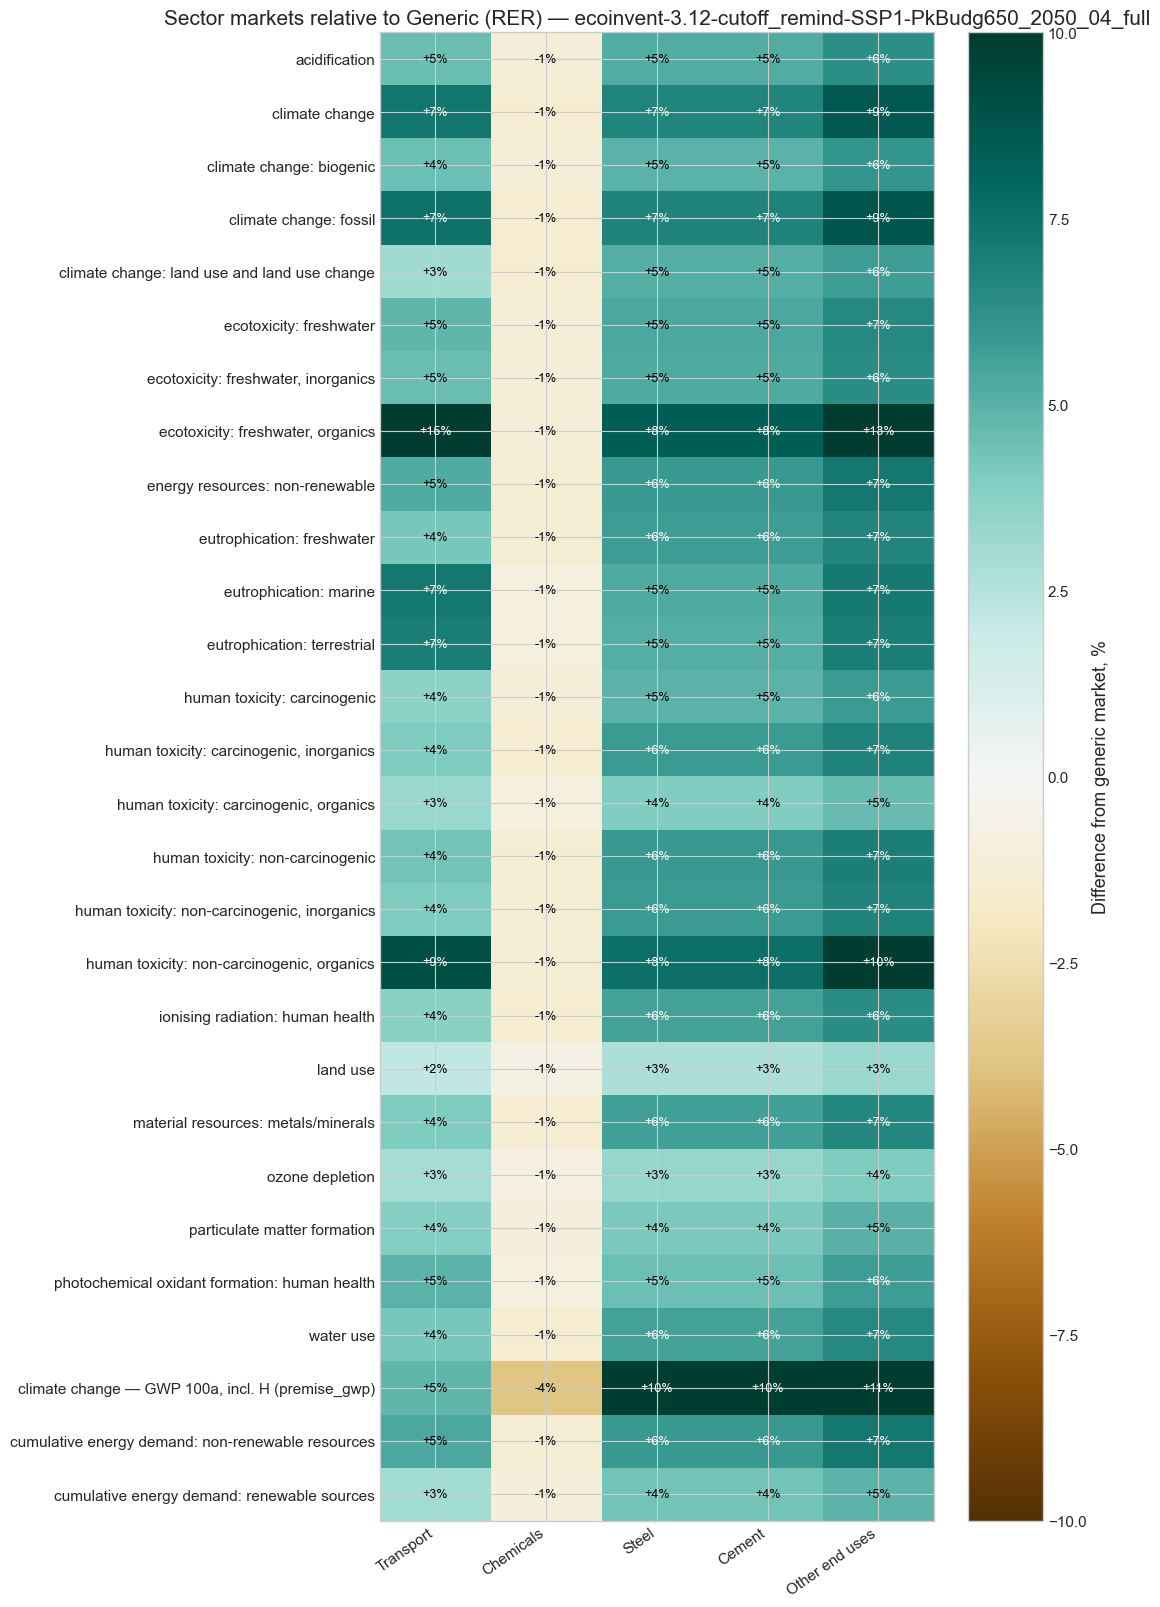

Saved C:\Users\ac145674\coding_projects\premise_h2-distribution\examples\h2-distribution_LCIA\results\03_ef31_spider_ratios.png


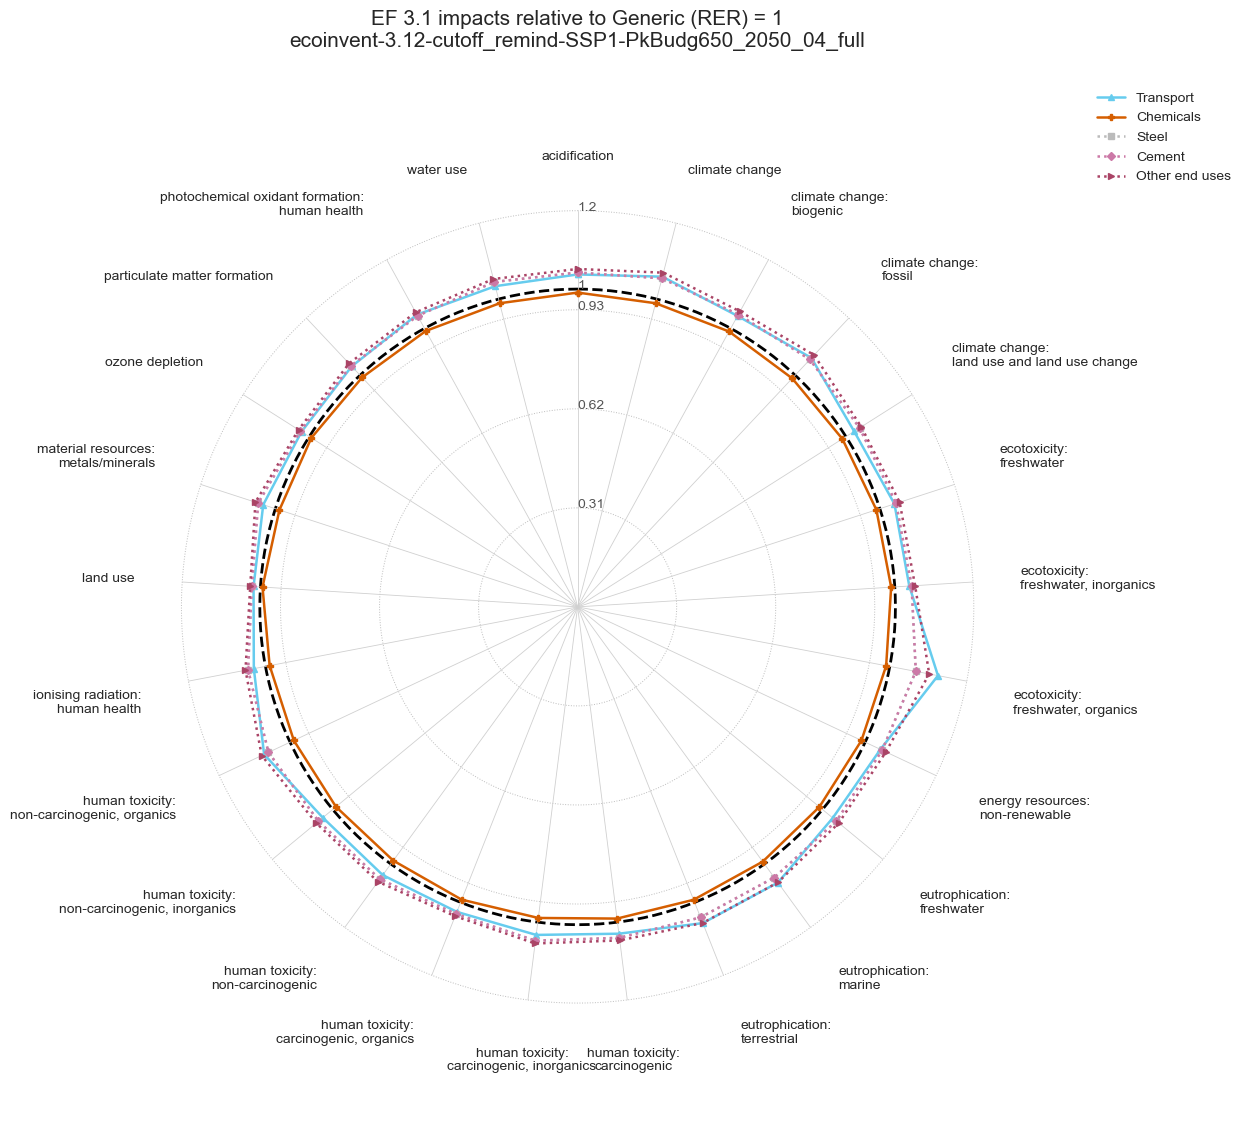

Saved C:\Users\ac145674\coding_projects\premise_h2-distribution\examples\h2-distribution_LCIA\results\04_selected_impact_hotspots.png


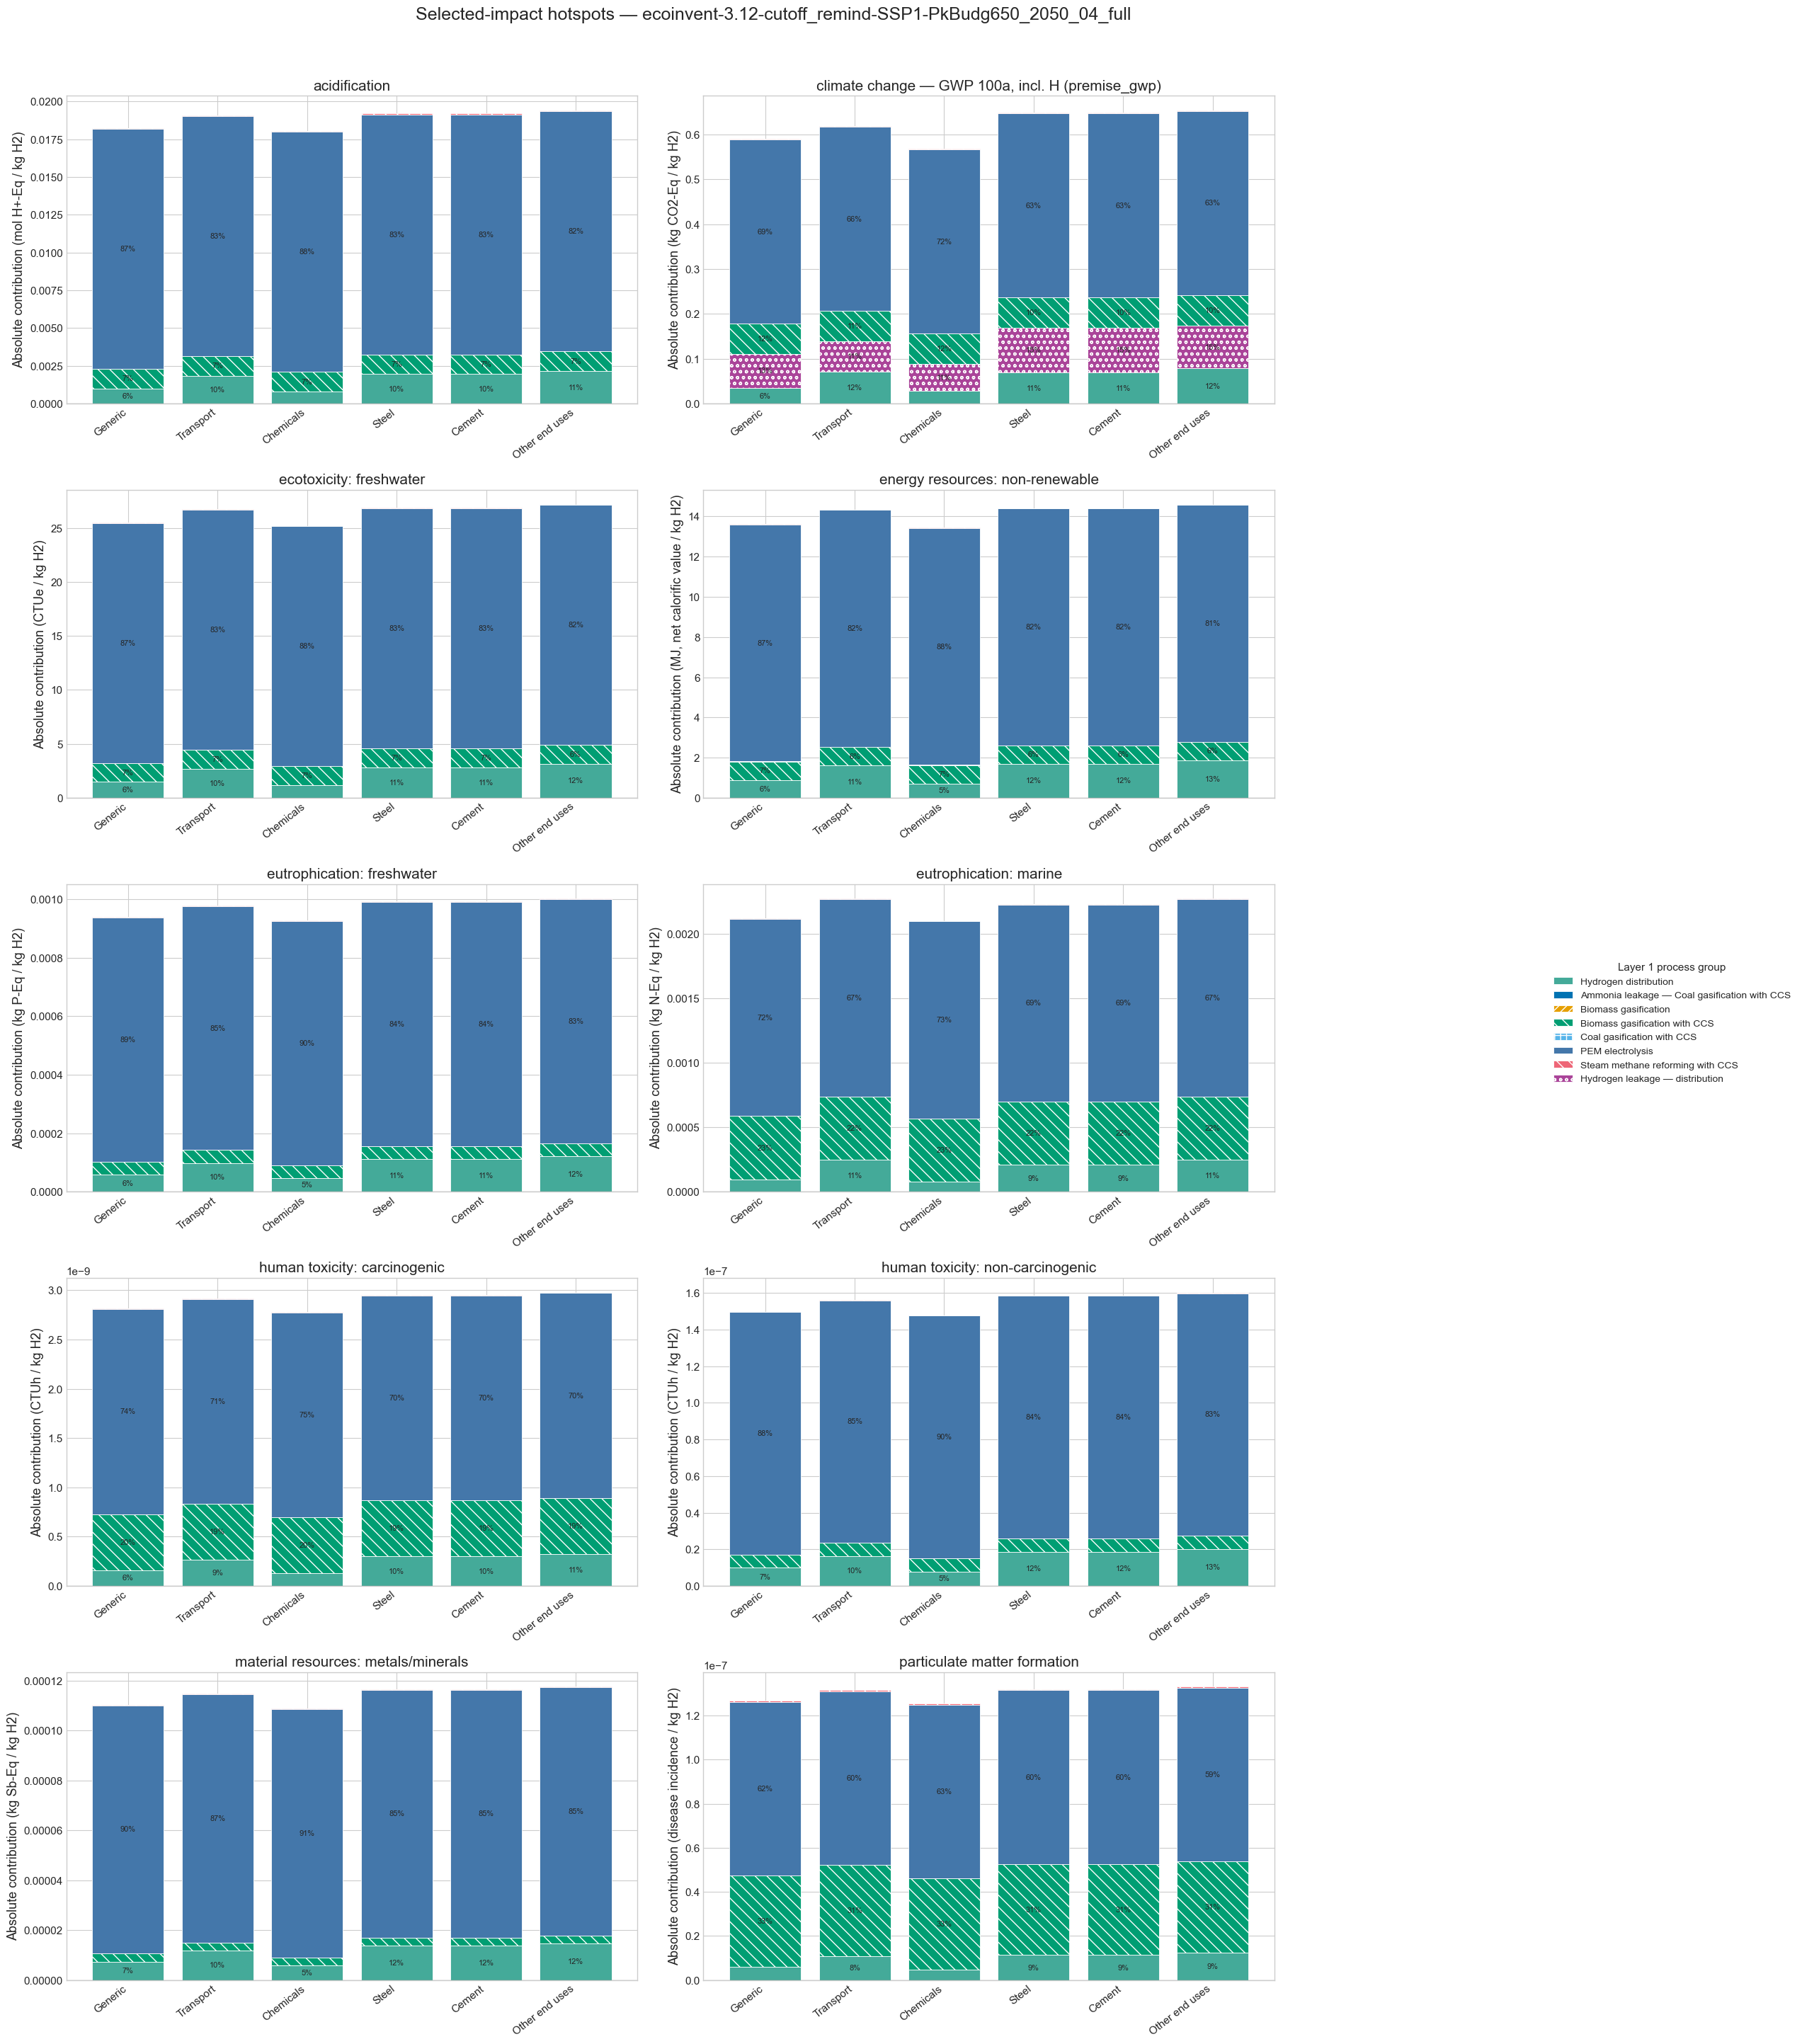

Saved C:\Users\ac145674\coding_projects\premise_h2-distribution\examples\h2-distribution_LCIA\results\05_stage_layer1.png


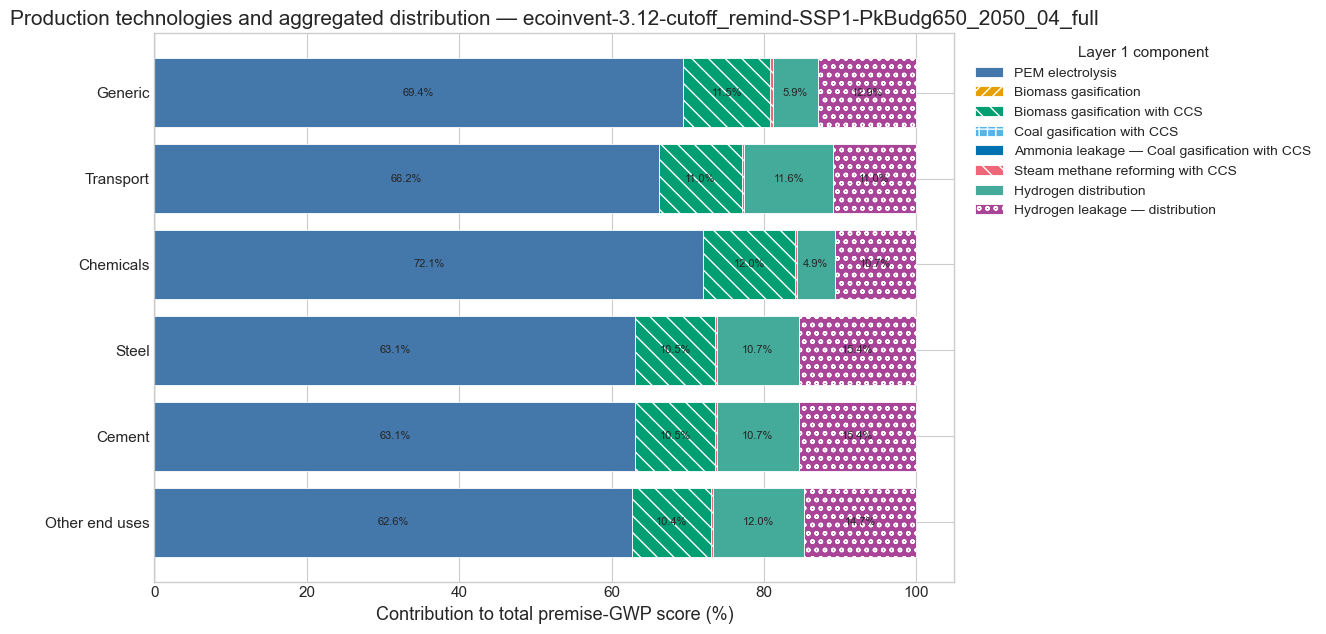

Saved C:\Users\ac145674\coding_projects\premise_h2-distribution\examples\h2-distribution_LCIA\results\06_distribution_layer2.png


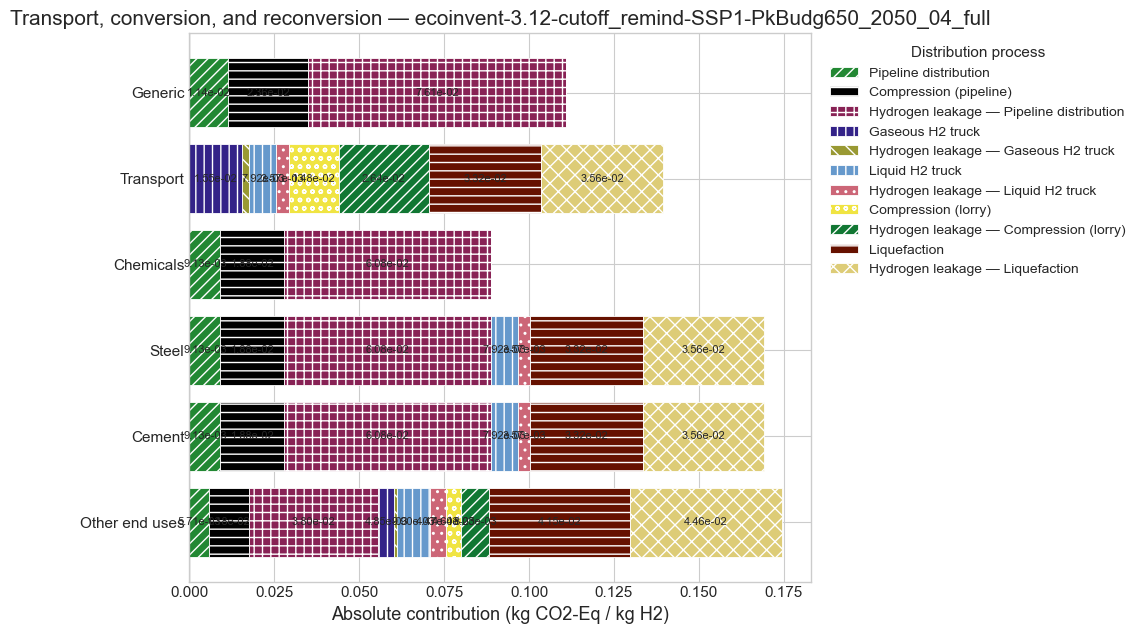

In [ ]:
for result in results_by_database.values():
    #plot_absolute_impacts(result)
    plot_baseline_heatmap(result)
    plot_ef_spider(result)
    plot_hotspots(result)
    plot_stage_layer1(result)
    plot_distribution_layer2(result)
    if RUN_REGIONAL_STEEL:
        steel_order = result.table('Steel-region order')['region'].tolist()
        plot_stage_layer1(result, 'Steel-region Layer 1', steel_order, 'steel stage layer 1')
        plot_distribution_layer2(result, 'Steel-region distribution', steel_order, 'steel distribution layer 2')

## 7. Numerical results and exports

All CSV files are written by `run_analysis.py`. Plot files are written by this notebook. The paths below are the complete handoff for each selected database.

In [ ]:
for database_name, result in results_by_database.items():
    print(f'\n{database_name}')
    if EXPORT_RESULTS:
        display(pd.DataFrame([{'table': label, 'path': str(path)} for label, path in result.export_paths.items()]))
    display(result.table('scores').sort_values(['impact category', 'market']))
    display(result.table('RER comparison'))
    display(result.table('Hotspot process groups'))
    display(result.table('Stage Layer 1'))
    display(result.table('Production input groups'))
    display(result.table('Distribution processes'))


ecoinvent-3.12-cutoff_remind-SSP1-PkBudg650_2050_04_full


,table,path
0,selection,C:\Users\ac145674\coding_projects\premise_h2-distribution\examples\h2-distribution_LCIA\results\hydrogen_markets_europe_selection.csv
1,methods,C:\Users\ac145674\coding_projects\premise_h2-distribution\examples\h2-distribution_LCIA\results\hydrogen_markets_europe_methods.csv
2,scores,C:\Users\ac145674\coding_projects\premise_h2-distribution\examples\h2-distribution_LCIA\results\hydrogen_markets_europe_lcia_scores_per_...
3,RER comparison,C:\Users\ac145674\coding_projects\premise_h2-distribution\examples\h2-distribution_LCIA\results\hydrogen_markets_europe_vs_generic_RER.csv
4,EF 3.1 spider ratios,C:\Users\ac145674\coding_projects\premise_h2-distribution\examples\h2-distribution_LCIA\results\hydrogen_markets_europe_ef31_ratios_vs_g...
5,Hotspot process groups,C:\Users\ac145674\coding_projects\premise_h2-distribution\examples\h2-distribution_LCIA\results\hydrogen_markets_europe_hotspot_process_...
6,Hotspot reconciliation,C:\Users\ac145674\coding_projects\premise_h2-distribution\examples\h2-distribution_LCIA\results\hydrogen_markets_europe_hotspot_reconcil...
7,contributions,C:\Users\ac145674\coding_projects\premise_h2-distribution\examples\h2-distribution_LCIA\results\hydrogen_markets_europe_lcia_process_con...
8,Stage Layer 1,C:\Users\ac145674\coding_projects\premise_h2-distribution\examples\h2-distribution_LCIA\results\hydrogen_markets_europe_stage_layer1.csv
9,Production inputs detailed,C:\Users\ac145674\coding_projects\premise_h2-distribution\examples\h2-distribution_LCIA\results\hydrogen_markets_europe_production_input...


,market,market name,location,impact category,indicator,method,unit,score per kg H2
112,Cement,"market for hydrogen, gaseous, low pressure, for cement",EUR,acidification,accumulated exceedance (AE),"(EF v3.1, acidification, accumulated exceedance (AE))",mol H+-Eq,0.019197
56,Chemicals,"market for hydrogen, gaseous, low pressure, for chemicals",EUR,acidification,accumulated exceedance (AE),"(EF v3.1, acidification, accumulated exceedance (AE))",mol H+-Eq,0.018044
0,Generic,"market for hydrogen, gaseous, low pressure",RER,acidification,accumulated exceedance (AE),"(EF v3.1, acidification, accumulated exceedance (AE))",mol H+-Eq,0.018245
140,Other end uses,"market for hydrogen, gaseous, low pressure, for other end uses",EUR,acidification,accumulated exceedance (AE),"(EF v3.1, acidification, accumulated exceedance (AE))",mol H+-Eq,0.019400
84,Steel,"market for hydrogen, gaseous, low pressure, for steel",EUR,acidification,accumulated exceedance (AE),"(EF v3.1, acidification, accumulated exceedance (AE))",mol H+-Eq,0.019197
...,...,...,...,...,...,...,...,...
80,Chemicals,"market for hydrogen, gaseous, low pressure, for chemicals",EUR,water use,user deprivation potential (deprivation-weighted water consumption),"(EF v3.1, water use, user deprivation potential (deprivation-weighted water consumption))",m3 world Eq deprived,1.918035
24,Generic,"market for hydrogen, gaseous, low pressure",RER,water use,user deprivation potential (deprivation-weighted water consumption),"(EF v3.1, water use, user deprivation potential (deprivation-weighted water consumption))",m3 world Eq deprived,1.944534
164,Other end uses,"market for hydrogen, gaseous, low pressure, for other end uses",EUR,water use,user deprivation potential (deprivation-weighted water consumption),"(EF v3.1, water use, user deprivation potential (deprivation-weighted water consumption))",m3 world Eq deprived,2.071278
108,Steel,"market for hydrogen, gaseous, low pressure, for steel",EUR,water use,user deprivation potential (deprivation-weighted water consumption),"(EF v3.1, water use, user deprivation potential (deprivation-weighted water consumption))",m3 world Eq deprived,2.052598


,market,market name,location,impact category,indicator,method,unit,score per kg H2,baseline score per kg H2,absolute difference,difference (%),baseline
0,Transport,"market for hydrogen, gaseous, low pressure, for transport",EUR,acidification,accumulated exceedance (AE),"(EF v3.1, acidification, accumulated exceedance (AE))",mol H+-Eq,0.019086,0.018245,0.000840,4.606125,Generic
1,Transport,"market for hydrogen, gaseous, low pressure, for transport",EUR,climate change,global warming potential (GWP100),"(EF v3.1, climate change, global warming potential (GWP100))",kg CO2-Eq,0.526618,0.490947,0.035671,7.265711,Generic
2,Transport,"market for hydrogen, gaseous, low pressure, for transport",EUR,climate change: biogenic,global warming potential (GWP100),"(EF v3.1, climate change: biogenic, global warming potential (GWP100))",kg CO2-Eq,0.006122,0.005860,0.000262,4.469171,Generic
3,Transport,"market for hydrogen, gaseous, low pressure, for transport",EUR,climate change: fossil,global warming potential (GWP100),"(EF v3.1, climate change: fossil, global warming potential (GWP100))",kg CO2-Eq,0.502562,0.467687,0.034875,7.456976,Generic
4,Transport,"market for hydrogen, gaseous, low pressure, for transport",EUR,climate change: land use and land use change,global warming potential (GWP100),"(EF v3.1, climate change: land use and land use change, global warming potential (GWP100))",kg CO2-Eq,0.017934,0.017401,0.000534,3.066720,Generic
...,...,...,...,...,...,...,...,...,...,...,...,...
135,Other end uses,"market for hydrogen, gaseous, low pressure, for other end uses",EUR,photochemical oxidant formation: human health,tropospheric ozone concentration increase,"(EF v3.1, photochemical oxidant formation: human health, tropospheric ozone concentration increase)",kg NMVOC-Eq,0.007055,0.006670,0.000385,5.772932,Generic
136,Other end uses,"market for hydrogen, gaseous, low pressure, for other end uses",EUR,water use,user deprivation potential (deprivation-weighted water consumption),"(EF v3.1, water use, user deprivation potential (deprivation-weighted water consumption))",m3 world Eq deprived,2.071278,1.944534,0.126744,6.517976,Generic
137,Other end uses,"market for hydrogen, gaseous, low pressure, for other end uses",EUR,"climate change — GWP 100a, incl. H (premise_gwp)","GWP 100a, incl. H","(IPCC 2021, climate change, GWP 100a, incl. H)",kg CO2-Eq,0.652984,0.589634,0.063351,10.744116,Generic
138,Other end uses,"market for hydrogen, gaseous, low pressure, for other end uses",EUR,cumulative energy demand: non-renewable resources,energy content (HHV),"(Cumulative Energy Demand (CED), energy resources: non-renewable, energy content (HHV))",MJ-Eq,14.928258,13.920362,1.007896,7.240444,Generic


,market,method,impact category,unit,layer 1 group,component,absolute contribution,score per kg H2,share of total impact (%)
0,Cement,"(EF v3.1, acidification, accumulated exceedance (AE))",acidification,mol H+-Eq,Hydrogen distribution,Hydrogen distribution,1.956078e-03,1.919670e-02,10.189658
1,Cement,"(EF v3.1, acidification, accumulated exceedance (AE))",acidification,mol H+-Eq,Hydrogen distribution,Hydrogen leakage — distribution,0.000000e+00,1.919670e-02,0.000000
2,Cement,"(EF v3.1, acidification, accumulated exceedance (AE))",acidification,mol H+-Eq,Production technology,Ammonia leakage — Coal gasification with CCS,2.289445e-08,1.919670e-02,0.000119
3,Cement,"(EF v3.1, acidification, accumulated exceedance (AE))",acidification,mol H+-Eq,Production technology,Biomass gasification,1.013740e-08,1.919670e-02,0.000053
4,Cement,"(EF v3.1, acidification, accumulated exceedance (AE))",acidification,mol H+-Eq,Production technology,Biomass gasification with CCS,1.305559e-03,1.919670e-02,6.800957
...,...,...,...,...,...,...,...,...,...
475,Transport,"(EF v3.1, particulate matter formation, impact on human health)",particulate matter formation,disease incidence,Production technology,Biomass gasification,4.072599e-13,1.314845e-07,0.000310
476,Transport,"(EF v3.1, particulate matter formation, impact on human health)",particulate matter formation,disease incidence,Production technology,Biomass gasification with CCS,4.133132e-08,1.314845e-07,31.434367
477,Transport,"(EF v3.1, particulate matter formation, impact on human health)",particulate matter formation,disease incidence,Production technology,Coal gasification with CCS,1.174331e-13,1.314845e-07,0.000089
478,Transport,"(EF v3.1, particulate matter formation, impact on human health)",particulate matter formation,disease incidence,Production technology,PEM electrolysis,7.880295e-08,1.314845e-07,59.933260


,market,layer 1 group,component,contribution type,score,share of market (%),physical amount,physical unit,method,impact category,unit
0,Generic,Production technology,PEM electrolysis,Technology excluding leakage,4.089669e-01,69.359502,NaN,NaN,"(IPCC 2021, climate change, GWP 100a, incl. H)","climate change — GWP 100a, incl. H (premise_gwp)",kg CO2-Eq
1,Generic,Production technology,Biomass gasification,Technology excluding leakage,4.744883e-07,0.000080,NaN,NaN,"(IPCC 2021, climate change, GWP 100a, incl. H)","climate change — GWP 100a, incl. H (premise_gwp)",kg CO2-Eq
2,Generic,Production technology,Biomass gasification with CCS,Technology excluding leakage,6.783513e-02,11.504625,NaN,NaN,"(IPCC 2021, climate change, GWP 100a, incl. H)","climate change — GWP 100a, incl. H (premise_gwp)",kg CO2-Eq
3,Generic,Production technology,Coal gasification with CCS,Technology excluding leakage,4.839447e-06,0.000821,NaN,NaN,"(IPCC 2021, climate change, GWP 100a, incl. H)","climate change — GWP 100a, incl. H (premise_gwp)",kg CO2-Eq
4,Generic,Production technology,Ammonia leakage — Coal gasification with CCS,Ammonia leakage,0.000000e+00,0.000000,NaN,NaN,"(IPCC 2021, climate change, GWP 100a, incl. H)","climate change — GWP 100a, incl. H (premise_gwp)",kg CO2-Eq
5,Generic,Production technology,Steam methane reforming with CCS,Technology excluding leakage,1.794990e-03,0.304425,NaN,NaN,"(IPCC 2021, climate change, GWP 100a, incl. H)","climate change — GWP 100a, incl. H (premise_gwp)",kg CO2-Eq
6,Generic,Hydrogen distribution,Hydrogen distribution,Distribution excluding leakage,3.497339e-02,5.931377,NaN,NaN,"(IPCC 2021, climate change, GWP 100a, incl. H)","climate change — GWP 100a, incl. H (premise_gwp)",kg CO2-Eq
7,Generic,Hydrogen distribution,Hydrogen leakage — distribution,Hydrogen leakage,7.605783e-02,12.899170,0.006914,kilogram,"(IPCC 2021, climate change, GWP 100a, incl. H)","climate change — GWP 100a, incl. H (premise_gwp)",kg CO2-Eq
8,Transport,Production technology,PEM electrolysis,Technology excluding leakage,4.089669e-01,66.185357,NaN,NaN,"(IPCC 2021, climate change, GWP 100a, incl. H)","climate change — GWP 100a, incl. H (premise_gwp)",kg CO2-Eq
9,Transport,Production technology,Biomass gasification,Technology excluding leakage,4.744883e-07,0.000077,NaN,NaN,"(IPCC 2021, climate change, GWP 100a, incl. H)","climate change — GWP 100a, incl. H (premise_gwp)",kg CO2-Eq


,market,technology,input group,contribution type,score,score per kg H2,share of market (%),method,impact category,unit
0,Cement,Biomass gasification,Biomass feedstock,Upstream input,4.517839e-07,0.647782,0.000070,"(IPCC 2021, climate change, GWP 100a, incl. H)","climate change — GWP 100a, incl. H (premise_gwp)",kg CO2-Eq
1,Cement,Biomass gasification,Infrastructure,Upstream input,8.332638e-09,0.647782,0.000001,"(IPCC 2021, climate change, GWP 100a, incl. H)","climate change — GWP 100a, incl. H (premise_gwp)",kg CO2-Eq
2,Cement,Biomass gasification,Other direct emissions,Other direct emissions,0.000000e+00,0.647782,0.000000,"(IPCC 2021, climate change, GWP 100a, incl. H)","climate change — GWP 100a, incl. H (premise_gwp)",kg CO2-Eq
3,Cement,Biomass gasification,Water,Upstream input,1.437175e-08,0.647782,0.000002,"(IPCC 2021, climate change, GWP 100a, incl. H)","climate change — GWP 100a, incl. H (premise_gwp)",kg CO2-Eq
4,Cement,Biomass gasification with CCS,Biomass feedstock,Upstream input,4.142565e-02,0.647782,6.394999,"(IPCC 2021, climate change, GWP 100a, incl. H)","climate change — GWP 100a, incl. H (premise_gwp)",kg CO2-Eq
...,...,...,...,...,...,...,...,...,...,...
181,Transport,Steam methane reforming with CCS,Fossil feedstock,Upstream input,1.532774e-03,0.617911,0.248057,"(IPCC 2021, climate change, GWP 100a, incl. H)","climate change — GWP 100a, incl. H (premise_gwp)",kg CO2-Eq
182,Transport,Steam methane reforming with CCS,Infrastructure,Upstream input,9.976493e-05,0.617911,0.016146,"(IPCC 2021, climate change, GWP 100a, incl. H)","climate change — GWP 100a, incl. H (premise_gwp)",kg CO2-Eq
183,Transport,Steam methane reforming with CCS,Other direct emissions,Other direct emissions,1.232481e-05,0.617911,0.001995,"(IPCC 2021, climate change, GWP 100a, incl. H)","climate change — GWP 100a, incl. H (premise_gwp)",kg CO2-Eq
184,Transport,Steam methane reforming with CCS,Other raw materials,Upstream input,4.045259e-05,0.617911,0.006547,"(IPCC 2021, climate change, GWP 100a, incl. H)","climate change — GWP 100a, incl. H (premise_gwp)",kg CO2-Eq


,market,substage,process,process key,contribution type,score,share of market (%),physical amount,physical unit,method,impact category,unit
0,Generic,Transport,Pipeline distribution,"(ecoinvent-3.12-cutoff_remind-SSP1-PkBudg650_2050_04_full, 1ca5494e631d4f32b2e60db1f4bf79b9)",Process excluding leakage,0.011412,1.935480,NaN,NaN,"(IPCC 2021, climate change, GWP 100a, incl. H)","climate change — GWP 100a, incl. H (premise_gwp)",kg CO2-Eq
1,Generic,Conversion,Compression (pipeline),"(ecoinvent-3.12-cutoff_remind-SSP1-PkBudg650_2050_04_full, 26b9a7ca463c4f8b96495542403b5cc8)",Process excluding leakage,0.000005,0.000930,NaN,NaN,"(IPCC 2021, climate change, GWP 100a, incl. H)","climate change — GWP 100a, incl. H (premise_gwp)",kg CO2-Eq
2,Generic,Conversion,Compression (pipeline),"(ecoinvent-3.12-cutoff_remind-SSP1-PkBudg650_2050_04_full, 13f887da454449da9d91f12bd7f18f05)",Process excluding leakage,0.023556,3.994967,NaN,NaN,"(IPCC 2021, climate change, GWP 100a, incl. H)","climate change — GWP 100a, incl. H (premise_gwp)",kg CO2-Eq
3,Generic,Transport,Hydrogen leakage — Pipeline distribution,"(ecoinvent-3.12-cutoff_remind-SSP1-PkBudg650_2050_04_full, 1ca5494e631d4f32b2e60db1f4bf79b9)",Hydrogen leakage,0.076058,12.899170,0.006914,kilogram,"(IPCC 2021, climate change, GWP 100a, incl. H)","climate change — GWP 100a, incl. H (premise_gwp)",kg CO2-Eq
4,Transport,Transport,Gaseous H2 truck,"(ecoinvent-3.12-cutoff_remind-SSP1-PkBudg650_2050_04_full, 40a5fc7722ba48529ca9fe3d9ed28e86)",Process excluding leakage,0.015506,2.509401,NaN,NaN,"(IPCC 2021, climate change, GWP 100a, incl. H)","climate change — GWP 100a, incl. H (premise_gwp)",kg CO2-Eq
5,Transport,Transport,Hydrogen leakage — Gaseous H2 truck,"(ecoinvent-3.12-cutoff_remind-SSP1-PkBudg650_2050_04_full, 40a5fc7722ba48529ca9fe3d9ed28e86)",Hydrogen leakage,0.002200,0.356038,0.000200,kilogram,"(IPCC 2021, climate change, GWP 100a, incl. H)","climate change — GWP 100a, incl. H (premise_gwp)",kg CO2-Eq
6,Transport,Transport,Liquid H2 truck,"(ecoinvent-3.12-cutoff_remind-SSP1-PkBudg650_2050_04_full, 88060eb76a2945a7a83a07e1ade2d15e)",Process excluding leakage,0.007920,1.281662,NaN,NaN,"(IPCC 2021, climate change, GWP 100a, incl. H)","climate change — GWP 100a, incl. H (premise_gwp)",kg CO2-Eq
7,Transport,Transport,Hydrogen leakage — Liquid H2 truck,"(ecoinvent-3.12-cutoff_remind-SSP1-PkBudg650_2050_04_full, 88060eb76a2945a7a83a07e1ade2d15e)",Hydrogen leakage,0.003575,0.578562,0.000325,kilogram,"(IPCC 2021, climate change, GWP 100a, incl. H)","climate change — GWP 100a, incl. H (premise_gwp)",kg CO2-Eq
8,Transport,Conversion,Compression (lorry),"(ecoinvent-3.12-cutoff_remind-SSP1-PkBudg650_2050_04_full, 140fec13868a4f0ab927078173d067ae)",Process excluding leakage,0.014849,2.403040,NaN,NaN,"(IPCC 2021, climate change, GWP 100a, incl. H)","climate change — GWP 100a, incl. H (premise_gwp)",kg CO2-Eq
9,Transport,Conversion,Hydrogen leakage — Compression (lorry),"(ecoinvent-3.12-cutoff_remind-SSP1-PkBudg650_2050_04_full, 140fec13868a4f0ab927078173d067ae)",Hydrogen leakage,0.026400,4.272457,0.002400,kilogram,"(IPCC 2021, climate change, GWP 100a, incl. H)","climate change — GWP 100a, incl. H (premise_gwp)",kg CO2-Eq


## Interpretation checklist

1. Confirm the exact selection table, especially the generic `RER` versus sector-specific IAM geography.
2. Compare scores only within the same impact category and unit.
3. Treat missing sector markets as a scenario outcome, not an analysis failure.
4. Retain negative contributions and shares above 100%; these can represent credits and offsetting burdens.
5. Use the premise GWP result when hydrogen leakage characterization is required.
6. Read spider values as ratios to Generic (RER), not as EF-normalized or weighted scores.
7. Do not interpret any contribution plot unless its reconciliation table passes.